# P4-P7 Supplementary Experiments -- Analysis

Loads results from the four supplementary single-variable paradigms (P4 No-Windowing, P5 Shifted Bandpass, P6 Transfer Overt->Imagined, P7 Coarse-to-Fine) and compares each against its relevant baseline: descriptive statistics, a paired Wilcoxon signed-rank test per subject (mirroring the P2-vs-P3 Wilcoxon test already used in Bab 6), and an automatic go/no-go recommendation (Bab 6 candidate vs. Bab 7 future-work note).

This notebook is entirely separate from `BCI_Master_Journal_Q1_Final.ipynb` (the P1-P3 champion analysis) -- it reuses that notebook's table/figure style for visual consistency only, not its code or content. Kept deliberately simple: descriptive statistics and basic significance testing only, no SHAP/XAI.

> **Important:** launch Jupyter with `notebooks/` as the working directory, exactly like the champion notebook -- all relative paths here (figure output to `outputs/`) are anchored to `os.getcwd()`.

> **Note on data completeness:** every cell below is written to run against however many subjects currently have results on disk (0 to 12). Before the full 12-subject lab run has been executed, most cells will show partial results or a "not enough data yet" notice instead of crashing -- this is expected, not a bug.

In [1]:
import os
import sys
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

BACKEND_SRC = os.path.abspath(os.path.join(os.getcwd(), '..', 'backend', 'src'))
sys.path.append(BACKEND_SRC)

from config import MODELS_DIR  # noqa: E402  (path append must precede this import)
from models.classical_models import ClassicalClassifier  # noqa: E402

OUTPUTS_DIR = os.path.abspath(os.path.join(os.getcwd(), 'outputs'))
os.makedirs(OUTPUTS_DIR, exist_ok=True)

SUBJECT_IDS = [f'S{i}' for i in range(1, 13)]
ALPHA = 0.05
MIN_PAIRS_FOR_WILCOXON = 5  # scipy.stats.wilcoxon needs a handful of non-zero pairs to be meaningful

print(f'Backend src on path: {BACKEND_SRC}')
print(f'Figures will be saved to: {OUTPUTS_DIR}')

Backend src on path: E:\ANDIARS-ARCHIVE\TUGAS AKHIR\NEURANDIAR\Daftar Sidang Proposal\SKRIPSI\Source Code SKRIPSI\neurandiar-bci\backend\src
Figures will be saved to: E:\ANDIARS-ARCHIVE\TUGAS AKHIR\NEURANDIAR\Daftar Sidang Proposal\SKRIPSI\Source Code SKRIPSI\neurandiar-bci\notebooks\outputs


## Shared helpers

`load_fullscale_results` reads each paradigm's per-subject JSON results (written automatically by the corresponding `run_p*.py` script). `load_p3_baseline_accuracy` re-evaluates an already-trained, unmodified P1-P3 model on its own sealed test set -- pure read-only inference, never retraining -- to get the exact per-subject baseline figures needed for a paired comparison (P1-P3's own exported CSVs, e.g. T18, are aggregated mean/std only and cannot be paired per subject).

In [2]:
def weights_dir(pilar, exp_id):
    return os.path.join(MODELS_DIR, 'weights', pilar, exp_id)


def load_fullscale_results(pilar, stage_dir):
    d = weights_dir(pilar, stage_dir)
    results = {}
    for subj in SUBJECT_IDS:
        p = os.path.join(d, f'results_{subj}.json')
        if os.path.exists(p):
            with open(p) as f:
                results[subj] = json.load(f)
    return results


def load_p3_baseline_accuracy(exp_id, feat_group, subject_id, pilar='P3_SVM'):
    """Read-only re-evaluation of an already-trained P1-P3 model on its own
    sealed test set. Returns None if the artefact isn't present."""
    d = weights_dir(pilar, exp_id)
    model_path = os.path.join(d, f'SVM_{feat_group}_{exp_id}_{subject_id}.pkl')
    xtest_path = os.path.join(d, f'Xtest_SVM_{feat_group}_{exp_id}_{subject_id}.npy')
    ytest_path = os.path.join(d, f'ytest_SVM_{feat_group}_{exp_id}_{subject_id}.npy')
    if not all(os.path.exists(p) for p in (model_path, xtest_path, ytest_path)):
        return None
    model = ClassicalClassifier(model_type='svm', C=10)
    model.load_model(model_path)
    Xtest, ytest = np.load(xtest_path), np.load(ytest_path)
    return float(model.evaluate(Xtest, ytest))


def go_no_go_conclusion(p_value, mean_delta_pp, hypothesis_direction='positive', alpha=ALPHA):
    """Automatic go/no-go text per Langkah spec: 'layak Bab 6' if p < alpha AND the
    direction matches the hypothesis, else 'sebaiknya Bab 7 sebagai saran'."""
    if p_value is None or (isinstance(p_value, float) and np.isnan(p_value)):
        return 'INCONCLUSIVE -- belum cukup data berpasangan untuk uji Wilcoxon (butuh >= 5 subjek).'
    significant = p_value < alpha
    right_direction = (mean_delta_pp > 0) if hypothesis_direction == 'positive' else True
    if significant and right_direction:
        return (f'LAYAK DIPERTIMBANGKAN masuk Bab 6 -- perbedaan signifikan (p={p_value:.4f} < {alpha}) '
                f'dan searah dengan hipotesis awal (delta rata-rata {mean_delta_pp:+.2f}pp).')
    reason = 'tidak signifikan' if not significant else 'berlawanan arah dengan hipotesis'
    return (f'Sebaiknya masuk Bab 7 sebagai saran penelitian lanjutan -- {reason} '
            f'(p={p_value:.4f}, delta rata-rata {mean_delta_pp:+.2f}pp).')


go_no_go_summary = {}  # collected at the end into one final table

## P4 -- No-Windowing

Baseline: P3 `E0_Baseline` / Barlow (standard 5x1s windowing), the same feature group used by the champion. Hypothesis direction: **positive** (full-epoch training expected to help).

In [3]:
p4_results = load_fullscale_results('P4_NoWindowing', 'Fullscale_12Subj_E0')
if len(p4_results) == 0:
    print('P4 belum memiliki hasil (0/12 subjek) -- lewati bagian ini. Sel di bawah tetap aman '
          'dijalankan (tabel/kesimpulan kosong, tidak crash).')
else:
    print(f'P4: {len(p4_results)}/12 subjects completed so far.')

rows = []
for subj, r in p4_results.items():
    baseline_acc = load_p3_baseline_accuracy('E0_Baseline', 'barlow', subj)
    if baseline_acc is None:
        continue
    rows.append({
        'subject': subj,
        'p4_test_acc_pct': r['test_accuracy'] * 100,
        'baseline_test_acc_pct': baseline_acc * 100,
    })
p4_df = pd.DataFrame(rows)
if len(p4_df):
    p4_df['delta_pp'] = p4_df['p4_test_acc_pct'] - p4_df['baseline_test_acc_pct']
p4_df

P4 belum memiliki hasil (0/12 subjek) -- lewati bagian ini. Sel di bawah tetap aman dijalankan (tabel/kesimpulan kosong, tidak crash).


""


In [4]:
if len(p4_df) >= MIN_PAIRS_FOR_WILCOXON:
    _, p4_pvalue = wilcoxon(p4_df['p4_test_acc_pct'], p4_df['baseline_test_acc_pct'])
else:
    p4_pvalue = None
    print(f'Only {len(p4_df)} paired subject(s) available so far -- need >= {MIN_PAIRS_FOR_WILCOXON} for Wilcoxon.')

p4_mean_delta = p4_df['delta_pp'].mean() if len(p4_df) else float('nan')
print(f"P4 mean delta: {p4_mean_delta:+.2f}pp | n={len(p4_df)} | Wilcoxon p-value: {p4_pvalue}")

go_no_go_summary['P4 No-Windowing'] = go_no_go_conclusion(p4_pvalue, p4_mean_delta, 'positive')
print(go_no_go_summary['P4 No-Windowing'])

Only 0 paired subject(s) available so far -- need >= 5 for Wilcoxon.
P4 mean delta: +nanpp | n=0 | Wilcoxon p-value: None
INCONCLUSIVE -- belum cukup data berpasangan untuk uji Wilcoxon (butuh >= 5 subjek).


In [5]:
if len(p4_df) > 0:
    fig, ax = plt.subplots(figsize=(8, 5))
    x = np.arange(len(p4_df))
    width = 0.35
    ax.bar(x - width / 2, p4_df['baseline_test_acc_pct'], width, label='P3 E0/Barlow baseline')
    ax.bar(x + width / 2, p4_df['p4_test_acc_pct'], width, label='P4 No-Windowing')
    ax.set_xticks(x); ax.set_xticklabels(p4_df['subject'])
    ax.set_ylabel('Test accuracy (%)')
    ax.set_title('P4 No-Windowing vs. P3 E0/Barlow baseline, per subject')
    ax.legend()
    fig.tight_layout()
    fig.savefig(os.path.join(OUTPUTS_DIR, 'p4p7_p4_vs_baseline.png'), dpi=150)
    plt.show()
else:
    print('No P4 results yet to plot.')

No P4 results yet to plot.


## P5 -- Shifted Bandpass Filter

Baseline: P3 `E0_Baseline` / Barlow, same as P4 (both vary a preprocessing detail against the same standard-windowing reference). Hypothesis direction: **positive**.

In [6]:
p5_results = load_fullscale_results('P5_ShiftedBandpass', 'Fullscale_12Subj_E0')
if len(p5_results) == 0:
    print('P5 belum memiliki hasil (0/12 subjek) -- lewati bagian ini. Sel di bawah tetap aman '
          'dijalankan (tabel/kesimpulan kosong, tidak crash).')
else:
    print(f'P5: {len(p5_results)}/12 subjects completed so far.')

rows = []
for subj, r in p5_results.items():
    baseline_acc = load_p3_baseline_accuracy('E0_Baseline', 'barlow', subj)
    if baseline_acc is None:
        continue
    rows.append({
        'subject': subj,
        'p5_test_acc_pct': r['test_accuracy'] * 100,
        'baseline_test_acc_pct': baseline_acc * 100,
    })
p5_df = pd.DataFrame(rows)
if len(p5_df):
    p5_df['delta_pp'] = p5_df['p5_test_acc_pct'] - p5_df['baseline_test_acc_pct']
p5_df

P5 belum memiliki hasil (0/12 subjek) -- lewati bagian ini. Sel di bawah tetap aman dijalankan (tabel/kesimpulan kosong, tidak crash).


""


In [7]:
if len(p5_df) >= MIN_PAIRS_FOR_WILCOXON:
    _, p5_pvalue = wilcoxon(p5_df['p5_test_acc_pct'], p5_df['baseline_test_acc_pct'])
else:
    p5_pvalue = None
    print(f'Only {len(p5_df)} paired subject(s) available so far -- need >= {MIN_PAIRS_FOR_WILCOXON} for Wilcoxon.')

p5_mean_delta = p5_df['delta_pp'].mean() if len(p5_df) else float('nan')
print(f"P5 mean delta: {p5_mean_delta:+.2f}pp | n={len(p5_df)} | Wilcoxon p-value: {p5_pvalue}")

go_no_go_summary['P5 Shifted Bandpass'] = go_no_go_conclusion(p5_pvalue, p5_mean_delta, 'positive')
print(go_no_go_summary['P5 Shifted Bandpass'])

Only 0 paired subject(s) available so far -- need >= 5 for Wilcoxon.
P5 mean delta: +nanpp | n=0 | Wilcoxon p-value: None
INCONCLUSIVE -- belum cukup data berpasangan untuk uji Wilcoxon (butuh >= 5 subjek).


In [8]:
if len(p5_df) > 0:
    fig, ax = plt.subplots(figsize=(8, 5))
    x = np.arange(len(p5_df))
    width = 0.35
    ax.bar(x - width / 2, p5_df['baseline_test_acc_pct'], width, label='P3 E0/Barlow baseline')
    ax.bar(x + width / 2, p5_df['p5_test_acc_pct'], width, label='P5 Shifted Bandpass')
    ax.set_xticks(x); ax.set_xticklabels(p5_df['subject'])
    ax.set_ylabel('Test accuracy (%)')
    ax.set_title('P5 Shifted Bandpass vs. P3 E0/Barlow baseline, per subject')
    ax.legend()
    fig.tight_layout()
    fig.savefig(os.path.join(OUTPUTS_DIR, 'p4p7_p5_vs_baseline.png'), dpi=150)
    plt.show()
else:
    print('No P5 results yet to plot.')

No P5 results yet to plot.


## P6 -- Transfer Overt->Imagined

Baseline: P3 `E6_CrossModality_ImaginedOnly` / Barlow, reused (not retrained) -- already embedded per-subject in each result JSON as `baseline_test_accuracy`, so no separate P3 reload is needed here. Hypothesis direction: **positive** (extra overt-phase training data expected to help imagined-speech decoding).

In [9]:
p6_results = load_fullscale_results('P6_TransferOvertImagined', 'Fullscale_12Subj_E0')
if len(p6_results) == 0:
    print('P6 belum memiliki hasil (0/12 subjek) -- lewati bagian ini. Sel di bawah tetap aman '
          'dijalankan (tabel/kesimpulan kosong, tidak crash).')
else:
    print(f'P6: {len(p6_results)}/12 subjects completed so far.')

rows = []
for subj, r in p6_results.items():
    rows.append({
        'subject': subj,
        'baseline_test_acc_pct': r['baseline_test_accuracy'] * 100,
        'enriched_test_acc_pct': r['enriched_test_accuracy'] * 100,
        'delta_pp': r['delta_pp'],
        'n_overt_added': r['n_overt_added'],
        'sanity_ok': r['sanity_check']['shape_match'] and r['sanity_check']['value_match'],
    })
p6_df = pd.DataFrame(rows)
p6_df

P6 belum memiliki hasil (0/12 subjek) -- lewati bagian ini. Sel di bawah tetap aman dijalankan (tabel/kesimpulan kosong, tidak crash).


""


In [10]:
if len(p6_df) >= MIN_PAIRS_FOR_WILCOXON:
    _, p6_pvalue = wilcoxon(p6_df['enriched_test_acc_pct'], p6_df['baseline_test_acc_pct'])
else:
    p6_pvalue = None
    print(f'Only {len(p6_df)} paired subject(s) available so far -- need >= {MIN_PAIRS_FOR_WILCOXON} for Wilcoxon.')

p6_mean_delta = p6_df['delta_pp'].mean() if len(p6_df) else float('nan')
print(f"P6 mean delta: {p6_mean_delta:+.2f}pp | n={len(p6_df)} | Wilcoxon p-value: {p6_pvalue}")
if len(p6_df) and not p6_df['sanity_ok'].all():
    print('[WARNING] One or more subjects failed the P6 reconstruction sanity check -- review their result JSON before trusting this comparison.')

go_no_go_summary['P6 Transfer Overt->Imagined'] = go_no_go_conclusion(p6_pvalue, p6_mean_delta, 'positive')
print(go_no_go_summary['P6 Transfer Overt->Imagined'])

Only 0 paired subject(s) available so far -- need >= 5 for Wilcoxon.
P6 mean delta: +nanpp | n=0 | Wilcoxon p-value: None
INCONCLUSIVE -- belum cukup data berpasangan untuk uji Wilcoxon (butuh >= 5 subjek).


In [11]:
if len(p6_df) > 0:
    fig, ax = plt.subplots(figsize=(8, 5))
    x = np.arange(len(p6_df))
    width = 0.35
    ax.bar(x - width / 2, p6_df['baseline_test_acc_pct'], width, label='P3 E6/Barlow baseline (imagined-only)')
    ax.bar(x + width / 2, p6_df['enriched_test_acc_pct'], width, label='P6 enriched (imagined+overt)')
    ax.set_xticks(x); ax.set_xticklabels(p6_df['subject'])
    ax.set_ylabel('Test accuracy (%)')
    ax.set_title('P6 enriched vs. P3 E6/Barlow baseline, per subject')
    ax.legend()
    fig.tight_layout()
    fig.savefig(os.path.join(OUTPUTS_DIR, 'p4p7_p6_vs_baseline.png'), dpi=150)
    plt.show()
else:
    print('No P6 results yet to plot.')

No P6 results yet to plot.


## P7 -- Coarse-to-Fine Hierarchical Decoding

Two end-to-end metrics, plus each sub-model's own standalone accuracy for reference.

- **First-syllable e2e accuracy** (leakage-free, from the held-out window-level test split): compared against a per-subject P3 `E0_Baseline`/Barlow baseline computed the same way here (re-evaluate the already-trained flat 19-class model, filtered to the 9 first-syllable labels) -- this gives a genuinely paired 12-subject baseline, which the aggregated `T18_p3_per_syllable_recall.csv` alone cannot provide.
- **Full-word e2e accuracy**: no existing per-subject 12-wide word-accuracy baseline exists in this codebase to pair against (`train_word_assembler_s3.py` is S3-only; `train_word_assembler.py` pools all 12 subjects into one shared model instead of training 12 independent ones). Reported as descriptive statistics only, per "jika memungkinkan" in the task spec -- no Wilcoxon test is attempted for this metric.

In [12]:
p7_results = load_fullscale_results('P7_CoarseToFine', 'Fullscale_12Subj')
if len(p7_results) == 0:
    print('P7 belum memiliki hasil (0/12 subjek) -- lewati bagian ini. Sel di bawah tetap aman '
          'dijalankan (tabel/kesimpulan kosong, tidak crash).')
else:
    print(f'P7: {len(p7_results)}/12 subjects completed so far.')

rows = []
for subj, r in p7_results.items():
    row = {'subject': subj, 'first_syllable_e2e_pct': r['first_syllable_e2e']['accuracy'] * 100}
    fw = r['full_word_e2e']
    row['full_word_e2e_pct'] = fw['accuracy'] * 100 if fw.get('available') else np.nan
    for name in ('coarse', 'fine_A', 'fine_I', 'fine_E', 'sa_branch'):
        row[f'{name}_acc_pct'] = r['sub_models'][name]['test_accuracy'] * 100
    rows.append(row)
p7_df = pd.DataFrame(rows)
p7_df

P7: 12/12 subjects completed so far.


,subject,first_syllable_e2e_pct,full_word_e2e_pct,coarse_acc_pct,fine_A_acc_pct,fine_I_acc_pct,fine_E_acc_pct,sa_branch_acc_pct
0,S1,17.142857,14.285714,42.857143,40.000000,34.782609,73.333333,81.250000
1,S2,25.000000,7.142857,40.000000,47.826087,77.777778,50.000000,69.230769
2,S3,28.571429,13.888889,41.904762,65.116279,65.625000,76.190476,54.166667
3,S4,22.448980,2.702703,41.836735,52.380952,46.666667,55.555556,80.000000
4,S5,14.035088,18.518519,38.596491,44.000000,31.250000,63.636364,80.000000
5,S6,15.789474,10.000000,26.315789,28.571429,57.142857,50.000000,50.000000
6,S7,19.379845,12.500000,41.085271,52.083333,40.476190,50.000000,33.333333
7,S8,14.545455,5.263158,36.363636,48.837209,32.352941,38.095238,54.545455
8,S9,17.977528,18.918919,43.820225,37.142857,53.333333,82.352941,66.666667
9,S10,22.222222,12.500000,38.888889,62.745098,44.736842,75.000000,70.370370


In [13]:
FIRST_SYLLABLE_LABELS = {0, 2, 4, 6, 8, 10, 12, 14, 16}  # MA,MI,BE,PI,MAN,BO,LE,SA,TI


def load_p3_first_syllable_baseline_accuracy(subject_id):
    """Read-only re-evaluation of P3's flat E0/Barlow model, filtered to the 9
    first-syllable labels -- directly comparable to P7's first_syllable_e2e metric
    (both are plain accuracy on first-syllable-labelled test windows)."""
    d = weights_dir('P3_SVM', 'E0_Baseline')
    model_path = os.path.join(d, f'SVM_barlow_E0_Baseline_{subject_id}.pkl')
    xtest_path = os.path.join(d, f'Xtest_SVM_barlow_E0_Baseline_{subject_id}.npy')
    ytest_path = os.path.join(d, f'ytest_SVM_barlow_E0_Baseline_{subject_id}.npy')
    if not all(os.path.exists(p) for p in (model_path, xtest_path, ytest_path)):
        return None
    model = ClassicalClassifier(model_type='svm', C=10)
    model.load_model(model_path)
    Xtest, ytest = np.load(xtest_path), np.load(ytest_path)
    mask = np.isin(ytest, list(FIRST_SYLLABLE_LABELS))
    if mask.sum() == 0:
        return None
    y_pred = model.pipeline.predict(Xtest[mask])
    return float((y_pred == ytest[mask]).mean())


# Guarded for the len(p7_df) == 0 case (no P7 results on disk yet): pd.DataFrame([])
# has zero columns, so p7_df['subject'] would raise KeyError if accessed unconditionally.
if len(p7_df) > 0:
    baseline_vals = [load_p3_first_syllable_baseline_accuracy(s) for s in p7_df['subject']]
    # 'v is not None' (not 'v or np.nan') -- a genuine 0.0 accuracy must not be treated as missing;
    # P4's prior pilot already recorded an exact 0% result in this same codebase.
    p7_df['baseline_first_syllable_pct'] = [v * 100 if v is not None else np.nan for v in baseline_vals]
    p7_paired_df = p7_df.dropna(subset=['baseline_first_syllable_pct']).copy()
    p7_paired_df['delta_pp'] = p7_paired_df['first_syllable_e2e_pct'] - p7_paired_df['baseline_first_syllable_pct']
else:
    p7_paired_df = pd.DataFrame(columns=['subject', 'first_syllable_e2e_pct', 'baseline_first_syllable_pct', 'delta_pp'])

p7_paired_df[['subject', 'first_syllable_e2e_pct', 'baseline_first_syllable_pct', 'delta_pp']]

,subject,first_syllable_e2e_pct,baseline_first_syllable_pct,delta_pp
0,S1,17.142857,5.714286,11.428571
1,S2,25.000000,11.666667,13.333333
2,S3,28.571429,20.000000,8.571429
3,S4,22.448980,11.224490,11.224490
4,S5,14.035088,10.526316,3.508772
5,S6,15.789474,10.526316,5.263158
6,S7,19.379845,6.976744,12.403101
7,S8,14.545455,10.000000,4.545455
8,S9,17.977528,15.730337,2.247191
9,S10,22.222222,14.285714,7.936508


In [14]:
if len(p7_paired_df) >= MIN_PAIRS_FOR_WILCOXON:
    _, p7_pvalue = wilcoxon(p7_paired_df['first_syllable_e2e_pct'], p7_paired_df['baseline_first_syllable_pct'])
else:
    p7_pvalue = None
    print(f'Only {len(p7_paired_df)} paired subject(s) available so far -- need >= {MIN_PAIRS_FOR_WILCOXON} for Wilcoxon.')

p7_mean_delta = p7_paired_df['delta_pp'].mean() if len(p7_paired_df) else float('nan')
print(f"P7 first-syllable e2e mean delta: {p7_mean_delta:+.2f}pp | n={len(p7_paired_df)} | Wilcoxon p-value: {p7_pvalue}")

go_no_go_summary['P7 Coarse-to-Fine (first-syllable e2e)'] = go_no_go_conclusion(p7_pvalue, p7_mean_delta, 'positive')
print(go_no_go_summary['P7 Coarse-to-Fine (first-syllable e2e)'])

# 'full_word_e2e_pct' column only exists once p7_df has at least one row (see previous cell).
full_word_vals = p7_df['full_word_e2e_pct'].dropna() if 'full_word_e2e_pct' in p7_df.columns else pd.Series([], dtype=float)
if len(full_word_vals) > 0:
    print('\nFull-word e2e accuracy -- descriptive statistics only (see markdown note above):')
    print(full_word_vals.describe())
else:
    print('\nNo full-word e2e results available yet.')

P7 first-syllable e2e mean delta: +8.02pp | n=12 | Wilcoxon p-value: 0.00048828125
LAYAK DIPERTIMBANGKAN masuk Bab 6 -- perbedaan signifikan (p=0.0005 < 0.05) dan searah dengan hipotesis awal (delta rata-rata +8.02pp).

Full-word e2e accuracy -- descriptive statistics only (see markdown note above):
count    12.000000
mean     11.635774
std       5.168192
min       2.702703
25%       7.554945
50%      12.500000
75%      14.768340
max      18.918919
Name: full_word_e2e_pct, dtype: float64


C:\Users\ASUS\AppData\Local\Temp\ipykernel_18936\1489246883.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([p7_df[c].dropna() for c in sub_model_cols], labels=[c.replace('_acc_pct', '') for c in sub_model_cols])


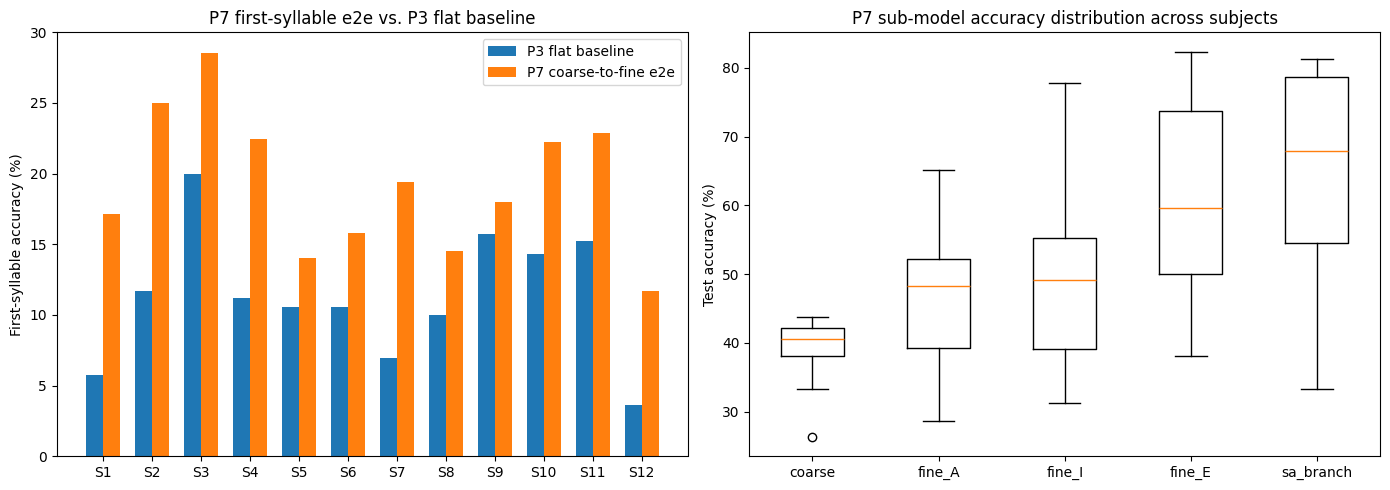

In [15]:
if len(p7_paired_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    x = np.arange(len(p7_paired_df))
    width = 0.35
    axes[0].bar(x - width / 2, p7_paired_df['baseline_first_syllable_pct'], width, label='P3 flat baseline')
    axes[0].bar(x + width / 2, p7_paired_df['first_syllable_e2e_pct'], width, label='P7 coarse-to-fine e2e')
    axes[0].set_xticks(x); axes[0].set_xticklabels(p7_paired_df['subject'])
    axes[0].set_ylabel('First-syllable accuracy (%)')
    axes[0].set_title('P7 first-syllable e2e vs. P3 flat baseline')
    axes[0].legend()

    sub_model_cols = ['coarse_acc_pct', 'fine_A_acc_pct', 'fine_I_acc_pct', 'fine_E_acc_pct', 'sa_branch_acc_pct']
    axes[1].boxplot([p7_df[c].dropna() for c in sub_model_cols], labels=[c.replace('_acc_pct', '') for c in sub_model_cols])
    axes[1].set_ylabel('Test accuracy (%)')
    axes[1].set_title('P7 sub-model accuracy distribution across subjects')

    fig.tight_layout()
    fig.savefig(os.path.join(OUTPUTS_DIR, 'p4p7_p7_summary.png'), dpi=150)
    plt.show()
else:
    print('No P7 results yet to plot.')

## Final Summary: Go/No-Go per Paradigm

Automatic recommendation per paradigm, computed from whatever data is currently on disk. "LAYAK Bab 6" requires both statistical significance (p < 0.05) AND the delta pointing in the hypothesized direction; otherwise the paradigm is flagged as a Bab 7 future-work note. This is descriptive tooling, not a final decision -- the researcher makes the actual Bab 6 / Bab 7 call after reviewing the full 12-subject results.

In [16]:
summary_df = pd.DataFrame(
    [{'paradigm': k, 'conclusion': v} for k, v in go_no_go_summary.items()]
)
pd.set_option('display.max_colwidth', None)
summary_df

,paradigm,conclusion
0,P4 No-Windowing,INCONCLUSIVE -- belum cukup data berpasangan untuk uji Wilcoxon (butuh >= 5 subjek).
1,P5 Shifted Bandpass,INCONCLUSIVE -- belum cukup data berpasangan untuk uji Wilcoxon (butuh >= 5 subjek).
2,P6 Transfer Overt->Imagined,INCONCLUSIVE -- belum cukup data berpasangan untuk uji Wilcoxon (butuh >= 5 subjek).
3,P7 Coarse-to-Fine (first-syllable e2e),LAYAK DIPERTIMBANGKAN masuk Bab 6 -- perbedaan signifikan (p=0.0005 < 0.05) dan searah dengan hipotesis awal (delta rata-rata +8.02pp).
